In [4]:
import os
import joblib
import numpy as np
import pandas as pd
from utils.metrics import qini_score

from models.gbdt_uplift_model import TwoStageGradientBoostingUpliftClassifier

DATASET_PATH = os.path.join(os.getcwd(), "data")

def run_experiment(dataset_alias, fold_id=0):
    print(f"\n{'='*50}")
    print(f"RUNNING EXPERIMENT: {dataset_alias} (Fold {fold_id})")
    print(f"{'='*50}")
    
    # 1. Load Dữ liệu
    folder = os.path.join(DATASET_PATH, f'{dataset_alias}_{fold_id}')
    train_path = os.path.join(folder, 'train.pkl')
    test_path = os.path.join(folder, 'test.pkl')
    
    if not os.path.exists(train_path):
        print(f"[Error] Data not found at {train_path}.")
        return

    train = joblib.load(train_path)
    test = joblib.load(test_path)
    
    print(train)
    
    # Lấy ra các thành phần X, y, t
    X_train, y_train, t_train = train['X'], train['y'], train['t']
    X_test, y_test, t_test = test['X'], test['y'], test['t']

    # Xác định có bao nhiêu loại Treatment (loại bỏ số 0 là Control)
    available_treatments = np.unique(t_train)
    treatment_ids = available_treatments[available_treatments != 0]
    
    print(f"Train Shape: {X_train.shape}")
    print(f"Treatments Found: {treatment_ids}")

    results = {}
    
    # 2. Vòng lặp train riêng cho từng cặp (Control vs Treatment_i)
    # Vì model hiện tại thiết kế cho Binary Treatment
    for t_id in treatment_ids:
        print(f"\n--- Processing Treatment {t_id} vs Control ---")
        
        # 2a. Lọc dữ liệu Train (Chỉ lấy dòng Control + Treatment hiện tại)
        mask_train = np.isin(t_train, [0, t_id])
        X_tr_sub = X_train[mask_train]
        y_tr_sub = y_train[mask_train]
        t_tr_sub = t_train[mask_train]
        
        # Map lại nhãn treatment về 0 và 1 (Control=0, Treat_i=1)
        t_tr_binary = (t_tr_sub == t_id).astype(np.int32)
        
        # 2b. Khởi tạo & Train Model
        print("  > Training Model...")
        model = TwoStageGradientBoostingUpliftClassifier(
            learning_rate=0.05,
            max_depth=6,
            n_estimators=300,        # Số lượng cây (bạn có thể tăng lên 1000 nếu có GPU mạnh)
            uplift_ensemble_weight=0.5, # Trọng số kết hợp (50% tin vào Outcome, 50% tin vào Uplift trực tiếp)
            verbose=100              # In log mỗi 100 vòng
        )
        
        # Fit model
        model.fit(X_tr_sub, y_tr_sub, t_tr_binary)
        
        # 2c. Dự đoán & Đánh giá trên tập Test
        # Cũng lọc tập test tương ứng
        mask_test = np.isin(t_test, [0, t_id])
        X_test_sub = X_test[mask_test]
        y_test_sub = y_test[mask_test]
        t_test_sub = t_test[mask_test]
        t_test_binary = (t_test_sub == t_id).astype(np.int32)
        
        # Predict trả về Uplift Score
        pred_uplift = model.predict(X_test_sub)
        
        # Tính Qini Score
        score = qini_score(y_test_sub, pred_uplift, t_test_binary)
        results[f'Treatment_{t_id}'] = score
        print(f"  > Done. Qini Score: {score:.4f}")

    return results


In [5]:
# --- Chạy thử Dataset Hillstrom (Fold 0) ---
# Hillstrom là dataset Marketing Email thực tế (Men's Email vs Women's Email)
scores_hillstrom = run_experiment('hillstrom', fold_id=0)
print("\nFinal Results (Hillstrom):", scores_hillstrom)

# --- Chạy thử Dataset Synthetic (Fold 0) ---
# Dataset giả lập với 6 loại treatment khác nhau
# scores_synth = run_experiment('synth1', fold_id=0)
# print("\nFinal Results (Synthetic):", scores_synth)


RUNNING EXPERIMENT: hillstrom (Fold 0)
{'X': array([[ 10.  ,   2.  , 142.44, ...,   0.  ,   0.  ,   0.  ],
       [  6.  ,   3.  , 329.08, ...,   1.  ,   1.  ,   1.  ],
       [  7.  ,   2.  , 180.65, ...,   0.  ,   1.  ,   1.  ],
       ...,
       [  6.  ,   1.  ,  29.99, ...,   2.  ,   1.  ,   0.  ],
       [  1.  ,   5.  , 552.94, ...,   0.  ,   1.  ,   2.  ],
       [  1.  ,   4.  , 472.82, ...,   0.  ,   0.  ,   1.  ]],
      dtype=float32), 'y': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 't': array([2, 0, 2, ..., 1, 2, 1]), 'trg': array([[nan, nan,  0.],
       [ 0., nan, nan],
       [nan, nan,  0.],
       ...,
       [nan,  0., nan],
       [nan, nan,  0.],
       [nan,  0., nan]], dtype=float32), 'p': array([[0.49979275, 0.5027319 ],
       [0.49979275, 0.5027319 ],
       [0.49979275, 0.5027319 ],
       ...,
       [0.49979275, 0.5027319 ],
       [0.49979275, 0.5027319 ],
       [0.49979275, 0.5027319 ]], dtype=float32)}
Train Shape: (51200, 8)
Treatments Found


>>> Running Experiment: hillstrom (Fold 0)
   Processing Treatment 1...
     > Raw Area: 1547403 | Random Area: 1547598
     > Qini Coef: -0.0053
   Processing Treatment 2...
     > Raw Area: 949203 | Random Area: 898482
     > Qini Coef: 1.4077


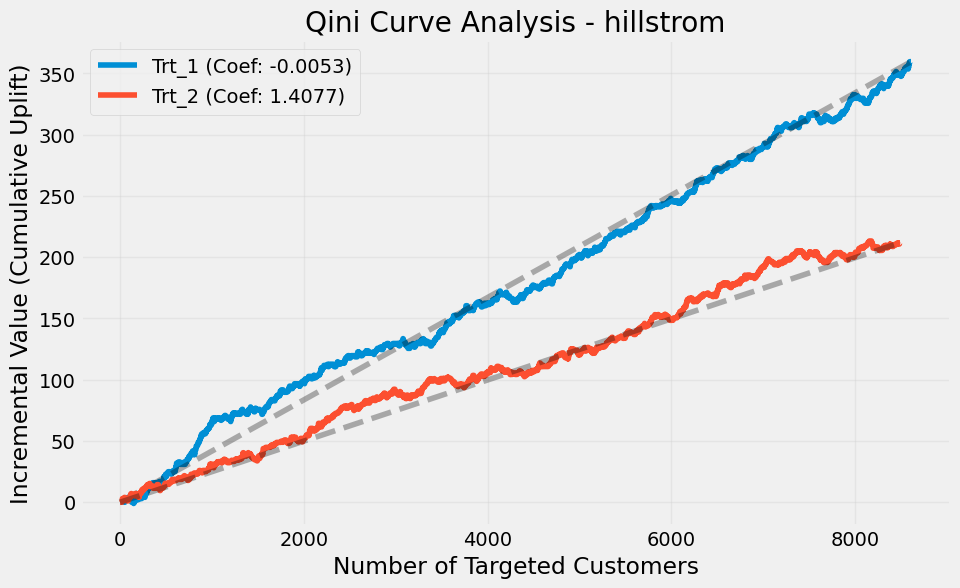

In [18]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc

# Import class model
from models.gbdt_uplift_model import TwoStageGradientBoostingUpliftClassifier

DATASET_PATH = os.path.join(os.getcwd(), "data")

def calculate_qini_data(y_true, uplift_score, treatment):
    """
    Tính toán các tọa độ (x, y) để vẽ Qini Curve.
    """
    # 1. Sắp xếp giảm dần theo điểm Uplift
    order = np.argsort(uplift_score)[::-1]
    y_true_sorted = y_true[order]
    treatment_sorted = treatment[order]
    
    # 2. Tính các chỉ số thống kê tổng
    N_t = np.sum(treatment_sorted == 1)
    N_c = np.sum(treatment_sorted == 0)
    
    # 3. Tính Cumulative Sum
    # Doanh thu tích lũy nhóm Treatment
    y_t_cumsum = np.cumsum(y_true_sorted * (treatment_sorted == 1))
    # Doanh thu tích lũy nhóm Control
    y_c_cumsum = np.cumsum(y_true_sorted * (treatment_sorted == 0))
    
    # 4. Tính Qini Curve (Gain thực tế)
    # Công thức: Y_treat - (Nt/Nc) * Y_control
    norm_factor = N_t / N_c if N_c > 0 else 0
    qini_curve = y_t_cumsum - y_c_cumsum * norm_factor
    
    # Thêm điểm (0,0)
    qini_curve = np.concatenate(([0], qini_curve))
    x_axis = np.arange(len(qini_curve))
    
    return x_axis, qini_curve

def plot_qini_comparison(results_dict, dataset_name):
    """
    Vẽ biểu đồ so sánh các Treatment.
    """
    plt.figure(figsize=(10, 6))
    
    for t_name, data in results_dict.items():
        x = data['x']
        y = data['y']
        auqc = data['auqc']
        coef = data['coef']
        
        # Vẽ đường Model
        plt.plot(x, y, label=f'{t_name} (Coef: {coef:.4f})')
        
        # Vẽ đường Random (cho từng treatment - lấy điểm cuối nối về 0)
        plt.plot([0, x[-1]], [0, y[-1]], 'k--', alpha=0.3)

    plt.title(f'Qini Curve Analysis - {dataset_name}')
    plt.xlabel('Number of Targeted Customers')
    plt.ylabel('Incremental Value (Cumulative Uplift)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def run_experiment(dataset_alias, fold_id=0):
    print(f"\n>>> Running Experiment: {dataset_alias} (Fold {fold_id})")
    
    # Load Data
    folder = os.path.join(DATASET_PATH, f'{dataset_alias}_{fold_id}')
    train = joblib.load(os.path.join(folder, 'train.pkl'))
    test = joblib.load(os.path.join(folder, 'test.pkl'))
    
    X_train, y_train, t_train = train['X'], train['y'], train['t']
    X_test, y_test, t_test = test['X'], test['y'], test['t']
    
    treatment_ids = np.unique(t_train[t_train != 0])
    plot_data = {}

    for t_id in treatment_ids:
        print(f"   Processing Treatment {t_id}...")
        
        # Filter Train Data
        mask_train = np.isin(t_train, [0, t_id])
        X_tr_sub = X_train[mask_train]
        y_tr_sub = y_train[mask_train]
        # Chuyển nhãn treatment về 0/1
        t_tr_binary = (t_train[mask_train] == t_id).astype(np.int32)
        
        # Train Model
        model = TwoStageGradientBoostingUpliftClassifier(
            learning_rate=0.03, # Giảm LR một chút cho ổn định
            max_depth=4,        # Giảm depth để tránh overfit
            n_estimators=200,
            uplift_ensemble_weight=0.5
        )
        model.fit(X_tr_sub, y_tr_sub, t_tr_binary)
        
        # Filter Test Data & Predict
        mask_test = np.isin(t_test, [0, t_id])
        X_test_sub = X_test[mask_test]
        y_test_sub = y_test[mask_test]
        t_test_binary = (t_test[mask_test] == t_id).astype(np.int32)
        
        uplift_scores = model.predict(X_test_sub)
        
        # Tính toán Qini Curves
        x_axis, y_curve = calculate_qini_data(y_test_sub, uplift_scores, t_test_binary)
        
        # Tính Area Under Curve (Diện tích thực tế)
        area_model = auc(x_axis, y_curve)
        
        # Tính Area Random (Diện tích đường chéo)
        area_random = (len(x_axis) * y_curve[-1]) / 2
        
        # --- CHUẨN HÓA (Qini Coefficient) ---
        # Qini Coef = (Area_Model - Area_Random) / (Area_Best - Area_Random)
        # Tuy nhiên, tính Area_Best (lý tưởng) rất phức tạp vì cần biết counterfactual.
        # Cách đơn giản thường dùng trong thi đấu (như CausalML):
        # Qini Coef = (Area_Model - Area_Random) / |Area_Random| (Hoặc chuẩn hóa theo N^2)
        # Ở đây ta dùng hiệu số diện tích đơn giản (Normalized by N*N/2 để ra range nhỏ)
        
        n_obs = len(x_axis)
        qini_coefficient = (area_model - area_random) / ( (n_obs * n_obs) / 2 ) * 1000 
        # Nhân 1000 để số dễ đọc hơn (scale tùy ý, quan trọng là dấu + / -)

        plot_data[f'Trt_{t_id}'] = {
            'x': x_axis, 
            'y': y_curve, 
            'auqc': area_model,
            'coef': qini_coefficient
        }
        
        print(f"     > Raw Area: {area_model:.0f} | Random Area: {area_random:.0f}")
        print(f"     > Qini Coef: {qini_coefficient:.4f}")

    # Vẽ biểu đồ tổng hợp
    plot_qini_comparison(plot_data, dataset_alias)

if __name__ == '__main__':
    # Chạy Hillstrom
    run_experiment('hillstrom', fold_id=0)
    
    # Nếu muốn chạy synthetic:
    # run_experiment('synth1', fold_id=0)